In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Configuración global de Seaborn
sns.set_theme(
style='whitegrid',
palette='muted',
font_scale=1.2
)
# Carga del dataset
df = pd.read_csv('cafeteria_universitaria_s8.csv')

# Ejercicio1 

In [2]:
df.dtypes

facultad                  object
turno                     object
dia_semana                object
tipo_pedido               object
metodo_pago               object
nivel_academico           object
semana_mes                 int64
gasto_total              float64
tiempo_espera_min        float64
calificacion_servicio    float64
items_pedido               int64
propina_porcentaje       float64
dtype: object

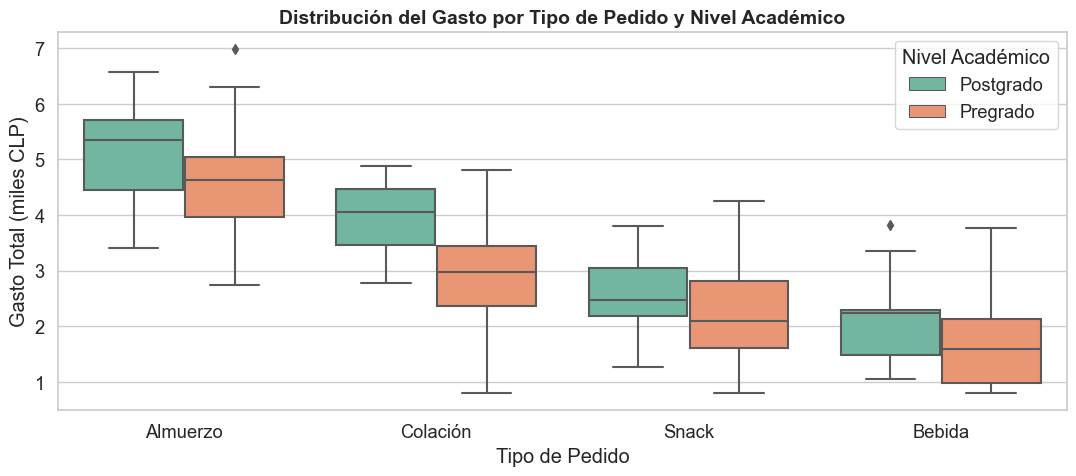

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(
data=df,
x='tipo_pedido',
y="gasto_total",
hue="nivel_academico",
palette="Set2",
order=['Almuerzo', 'Colación', 'Snack', 'Bebida'],
ax=ax
)
ax.set_title('Distribución del Gasto por Tipo de Pedido y Nivel Académico',
fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de Pedido')
ax.set_ylabel('Gasto Total (miles CLP)')
ax.legend(title='Nivel Académico', loc='upper right')
plt.tight_layout()
plt.show()

### ¿Qué tipo de pedido presenta la mayor variabilidad en el gasto total? Justifique utilizando el IQR visual. 

##### Las cajas de almuerzo son las más altas en comparación a las de Snack o Bebida cubriendo un rango de gasto mucho más amplio

### ¿Se observan outliers en alguna categoría? Si es así, ¿en qué tipo de pedido y nivel académico aparecen?

##### si, se observan valores atipicos: Almuerzo(pregrado): Hay un outlier superior que llega casi a los 7 mil CLP y Bebida(postgrado): Se observa un outlier superior que se acerca a los 4 mil CLP.


### ¿Existe una diferencia sistemática en el gasto entre estudiantes de Pregrado y Postgrado? ¿En qué categorías es más evidente? 

##### Sí, los estudiantes de Postgrado gastan mas que los de Pregrado en todas las categorías. Especialmente en la categoría de la colacion. la mediana de Postgrado en colación esta por encima de toda la caja de pregrado. También en el almuerzo, donde hay una separación super notoria entre las posiciones de ambas cajas.


# Ejercicio 2

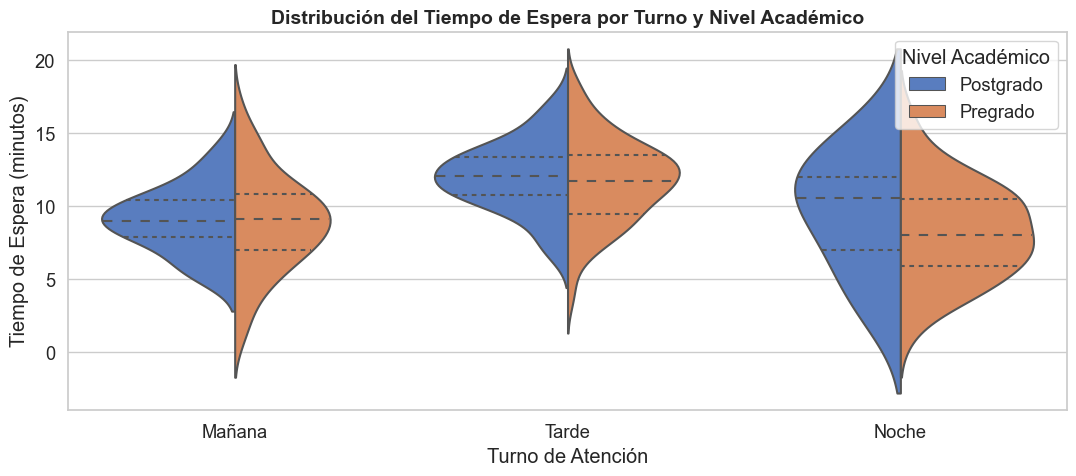

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.violinplot(
data=df,
x="turno",
y='tiempo_espera_min',
hue="nivel_academico",
split=True,
inner="quartile",
palette='muted',
order=['Mañana', 'Tarde', 'Noche'],
ax=ax
)
ax.set_title('Distribución del Tiempo de Espera por Turno y Nivel Académico',
fontsize=14, fontweight='bold')
ax.set_xlabel('Turno de Atención')
ax.set_ylabel('Tiempo de Espera (minutos)')
ax.legend(title='Nivel Académico')
plt.tight_layout()
plt.show()


### ¿En qué turno es mayor el tiempo de espera mediano? ¿Esto tiene sentido desde una perspectiva operacional?

##### El tiempo de espera mediano es mayor en el turno de la Tarde. en el sentido operacion tiene sentido ya que los turnos de la tarde coinciden con las altas demandas que se muestran, estos pueden congestionar y hacer mayores tiempos de espera

### ¿Las distribuciones del tiempo de espera son simétricas o presentan asimetría? ¿Hacia qué lado? 

##### Las distribuciones presentan asimetría, siendo más evidente en el turno de la Noche, Turno Tarde: Muestra poca asimetría hacia los valores altos, turno Noche: Es el más asimétrico. en el azul, hay una asimetría negativa (la mayoría espera mucho). En el naranja, hay una asimetría positiva (la mayoría espera poco)

### Compare boxplot vs. violinplot para los mismos datos. ¿Qué información adicional entrega el violinplot que el boxplot no muestra?

##### violinplot muestra la densidad de probabilidad de los datos. La forma de la distribución muestra visualmente dónde se agrupa la mayor cantidad de datos mediante el ancho del violin, ya que el boxplot solo te dice dónde está el 50% central sin mostrar cómo se distribuyen dentro de ese rango. y Visualiza mejor qué tan estirados o dispersos están los datos en los extremos sin depender solamente de los puntos de outliers.


# Ejercicio 3

Variables numéricas: ['semana_mes', 'gasto_total', 'tiempo_espera_min', 'calificacion_servicio', 'items_pedido', 'propina_porcentaje']

Matriz de correlación:
                       semana_mes  gasto_total  tiempo_espera_min  \
semana_mes                   1.00        -0.03              -0.07   
gasto_total                 -0.03         1.00               0.49   
tiempo_espera_min           -0.07         0.49               1.00   
calificacion_servicio        0.07        -0.16              -0.24   
items_pedido                -0.08         0.30               0.15   
propina_porcentaje           0.00         0.02              -0.04   

                       calificacion_servicio  items_pedido  propina_porcentaje  
semana_mes                              0.07         -0.08                0.00  
gasto_total                            -0.16          0.30                0.02  
tiempo_espera_min                      -0.24          0.15               -0.04  
calificacion_servicio            

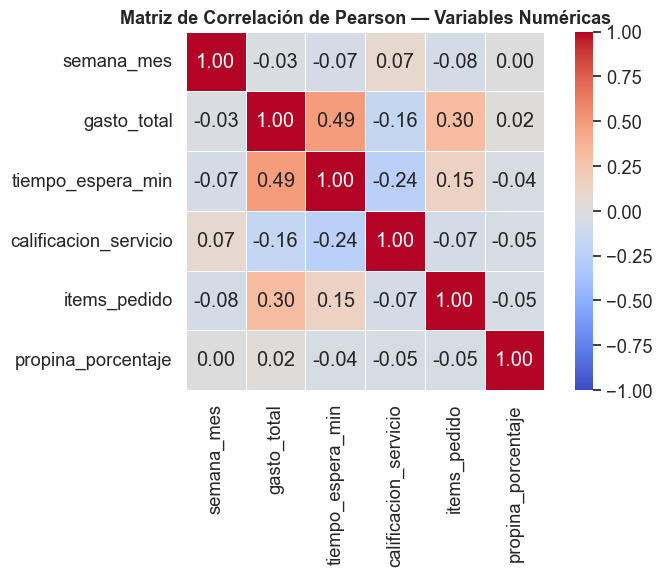

In [5]:
# Paso 1: Seleccionar solo columnas numéricas
num_cols = df.select_dtypes(include=np.number)
print('Variables numéricas:', list(num_cols.columns))
# Paso 2: Calcular la matriz de correlación de Pearson
corr_matrix = num_cols.corr()
print('\nMatriz de correlación:')
print(corr_matrix.round(2))

# Paso 3: Visualizar como heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    data=corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax
)

ax.set_title('Matriz de Correlación de Pearson — Variables Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### ¿Cuál es el par de variables con mayor correlación positiva? Indique el valor exacto y proponga una explicación causal plausible.

##### gasto_total y tiempo_espera_min., 0.49- mayor gasto da mas numero de platos por lo que la cocina requiere más tiempo para preparar pedidos

### ¿Existe correlación negativa entre tiempo_espera_min y calificacion_servicio? ¿Cuál es su valor? ¿Le parece razonable desde el punto de vista operacional? 

##### si, -0,24. En el sector servicios, el tiempo es un factor critico de satisfacción. mientras el tiempo de espera aumenta, la percepción de calidad del cliente suele disminuir

### ¿Qué variable numérica tiene la menor correlación promedio con el resto? ¿Qué implica esto para el análisis?

##### propina_porcentaje sus valores son los más cercanos a cero (0.00, 0.02, -0.04, -0.05, -0.05). analisis: la propina No parece estar influenciada por cuánto se gasta, cuánto se espera o incluso por la calificación del servicio. proablemente la propina depende de factores externos no capturados

# Ejercicio 4

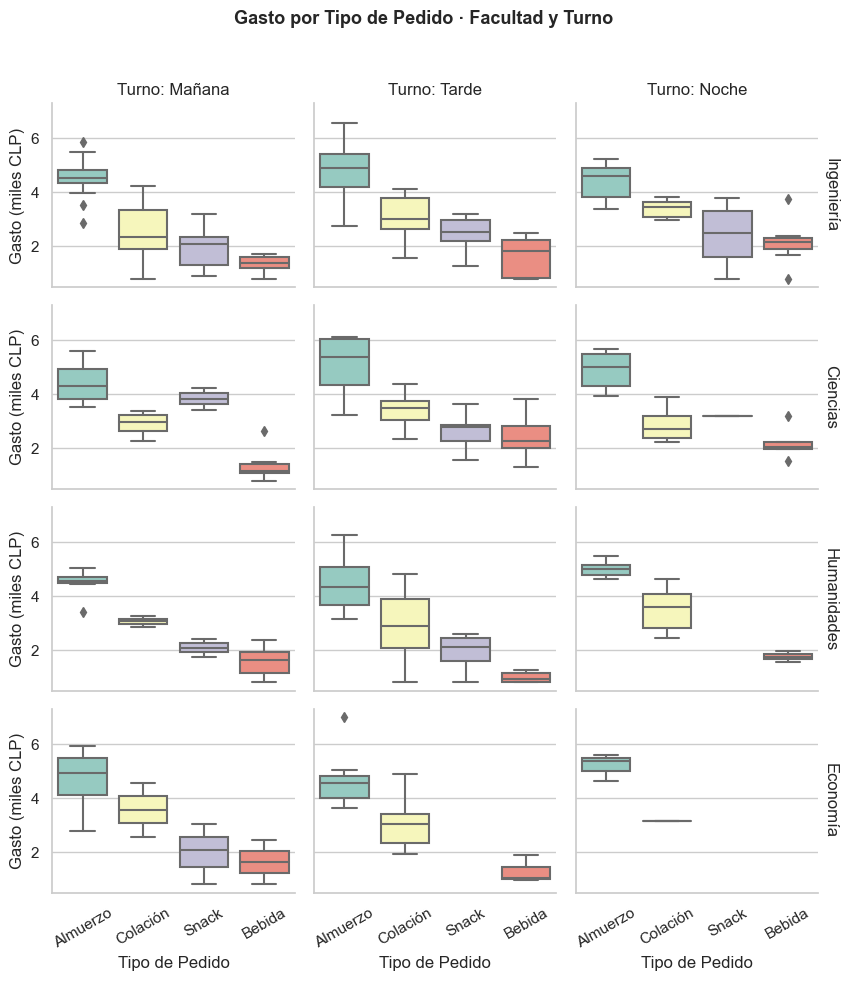

In [6]:
sns.set_theme(style='whitegrid', font_scale=1.0)
g = sns.FacetGrid(
    df,
    col='turno',
    row='facultad',
    col_order=['Mañana', 'Tarde', 'Noche'],
    row_order=['Ingeniería', 'Ciencias', 'Humanidades', 'Economía'],
    height=2.4,
    aspect=1.2,
    margin_titles=True
)

g.map_dataframe(
    sns.boxplot,
    x='tipo_pedido',
    y='gasto_total',
    palette='Set3',
    order=['Almuerzo', 'Colación', 'Snack', 'Bebida']
)

g.set_axis_labels('Tipo de Pedido', 'Gasto (miles CLP)')
g.set_titles(col_template='Turno: {col_name}', row_template='{row_name}')

g.figure.suptitle(
    'Gasto por Tipo de Pedido · Facultad y Turno',
    y=1.02, fontsize=13, fontweight='bold'
)
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
g.savefig('act4_facetgrid.png', dpi=300, bbox_inches='tight')
plt.show()

### ¿Qué combinación turno–facultad presenta el mayor gasto mediano en almuerzo? ¿Y el menor? 

##### Mayor gasto mediano: combinación Turno Tarde - Facultad de Ciencias. La mediana en este gráfico se sitúa  por encima de los 5000, superando ligeramente a las otras
##### Menor gasto mediano: combinación Turno Tarde - Facultad de Economía. la línea central de la caja verde está posicionada justo por encima de los 4000, siendo la más baja

### ¿El patrón de gasto por turno es consistente entre las cuatro facultades, o existen diferencias notables? Describa al menos un caso particular. 

##### En Ingeniería o Ciencias el gasto en "Almuerzo" tiende a mantenerse o subir en el turno tarde/noche, en Economía el gasto mediano en almuerzo cae significativamente en el turno tarde

### ¿Cuál es la ventaja del FacetGrid sobre generar los mismos gráficos manualmente con subplots? Fundamente su respuesta.

##### FacetGrid asegura automáticamente que todos los subgráficos compartan la misma escala en los ejes y en lugar de escribir un bucle manual FacetGrid mapea las variables de un DataFrame con una sola línea de lógica

# Ejercicio 5

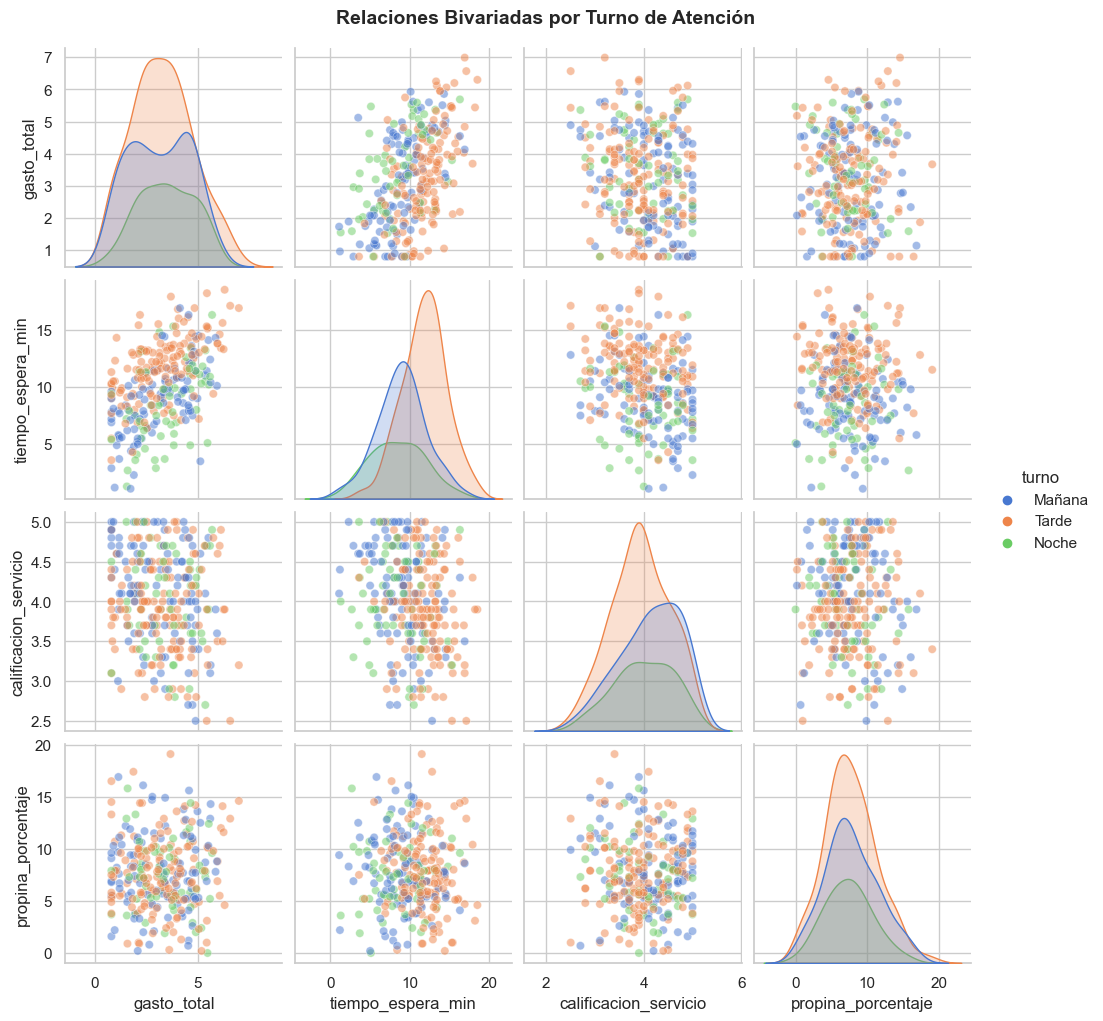

In [7]:
# Seleccionar variables numéricas de interés
vars_plot = ['gasto_total', 'tiempo_espera_min',
'calificacion_servicio', 'propina_porcentaje']
g = sns.pairplot(
df[vars_plot + ['turno']],
hue='turno',
hue_order=['Mañana', 'Tarde', 'Noche'],
diag_kind='kde',
plot_kws={'alpha': 0.5},
palette='muted'
)
g.figure.suptitle(
'Relaciones Bivariadas por Turno de Atención',
y=1.02, fontsize=14, fontweight='bold'
)
g.savefig('desafio_pairplot.svg', bbox_inches='tight') # SVG = calidad vectorial
plt.show()